In [17]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

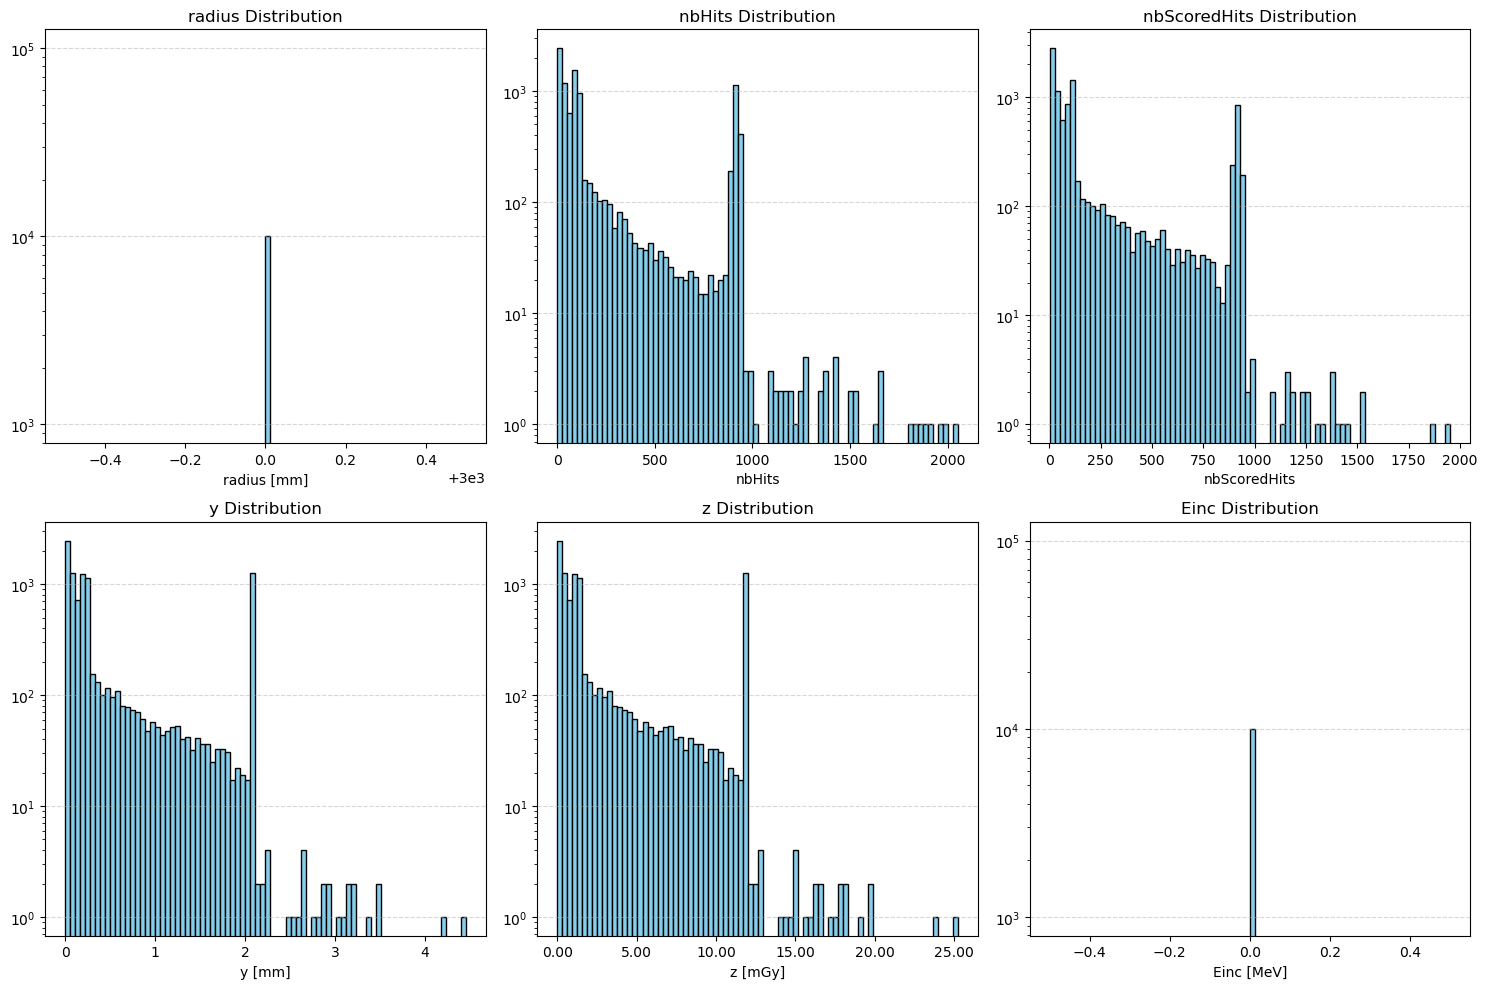

In [ ]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': None
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot semplice con range personalizzato
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log)
    # Tutti in scala logaritmica
    axes[i].set_yscale('log')
    axes[i].set_title(f'{col} Distribution')
    
    # Per z moltiplichiamo l'asse x per 1000 per ottenere tutto in mGy
    if col == 'z':
        axes[i].set_xlabel(f"{col} [mGy]")
        # In notazione scientifica con 2 decimali
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*1e3:.2f}'))
    else:
        axes[i].set_xlabel(f"{col}{units.get(col, '')}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

In [ ]:
custom_ranges = {
    'y': (0, 5),
    'z': (0, 0.02),
    'Einc': (0, 0.02)
}
plot_list = ['y', 'z']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for ax, col in zip(axes, plot_list):
    is_log = col in ['y', 'z']
    
    # Plot
    ax.hist(df[col], bins=80, range=custom_ranges.get(col), 
            color='skyblue', edgecolor='black', log=is_log)
    
    ax.set_title(f'{col} Distribution')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Formattazione etichette
    if col == 'z':
        ax.set_xlabel(f"{col} [mGy]")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*1000:.2f}'))
    else:
        ax.set_xlabel(f"{col}{units.get(col, '')}")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Calcoliamo $y_F$ e $z_F$.

In [ ]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']

# 1. Media in frequenza (y_F)
y_f = y_data.mean()

# 2. Media in dose (y_D)
# Formula: somma(y^2) / somma(y)
y_d = (y_data**2).sum() / y_data.sum()

# 3. Varianza e Deviazione Standard (della distribuzione in frequenza)
y_var = y_data.var()
y_std = y_data.std()

print(f"Media in frequenza: {y_f:.4f} keV/µm")
print(f"Media in dose: {y_d:.4f} keV/µm")
print(f"Deviazione standard: {y_std:.4f} keV/µm")
print(f"Numero di eventi considerati: {len(y_data)}")

Media in frequenza: 0.4493 keV/µm
Media in dose: 1.3608 keV/µm
Deviazione standard: 0.6421 keV/µm
Numero di eventi considerati: 153
